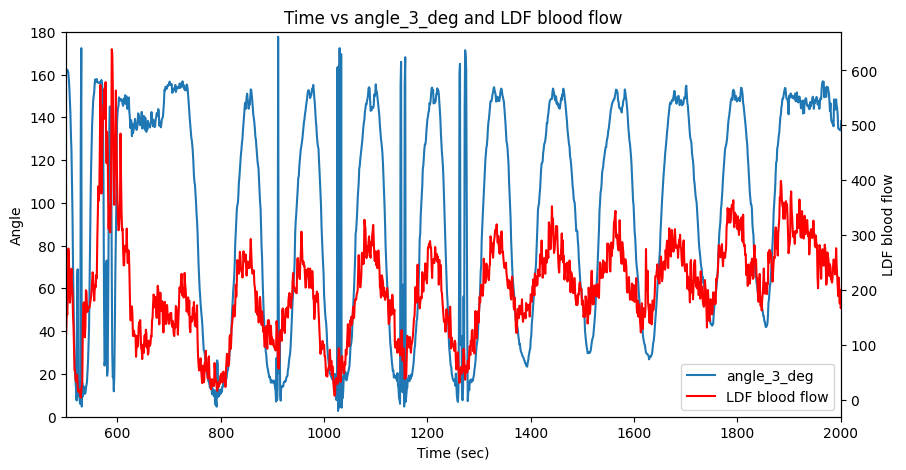

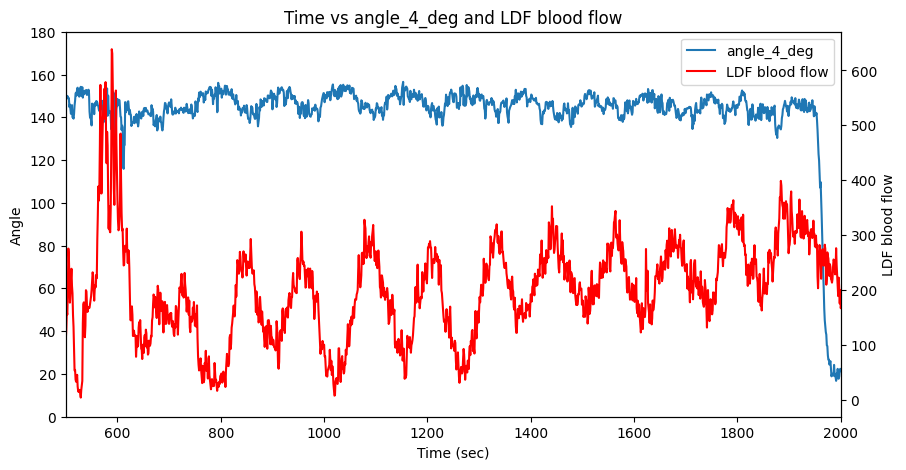

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("test_video.csv")

df = df[['Frame','angle_3_deg', 'angle_4_deg', 'LDF_bloodflow']]
df['LDF_bloodflow'] = df['LDF_bloodflow'].shift(40)
df['Frame'] = df['Frame'] / 3
time_col = "Frame"
ldf_col = "LDF_bloodflow"

#gets every column that starts with "angle_"
angle_cols = [col for col in df.columns if col.startswith("angle_")]

for angle_col in angle_cols:
    plt.figure(figsize=(10,5))

    #left y-axis: angle
    plt.plot(df[time_col], df[angle_col], label=angle_col)
    plt.xlabel("Time (sec)")
    plt.ylabel("Angle")
    plt.ylim(0, 180)

    #right y-axis: LDF blood flow
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax2.plot(df[time_col],df[ldf_col], label="LDF blood flow", color="red")
    ax2.set_ylabel("LDF blood flow")

    plt.title(f"Time vs {angle_col} and LDF blood flow")

    #combine legends from both y-axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)
    plt.xlim(500, 2000)

    plt.show()